<a href="https://colab.research.google.com/github/jdasam/ant5015/blob/2025/notebooks/sine_wav.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 사인파 합성하기

In [ ]:
import torch
import matplotlib.pyplot as plt
import IPython.display as ipd
from math import pi

torch.set_printoptions(sci_mode=False)

# 시간의 흐름에 해당하는 텐서 만들기
sample_t = torch.arange(48000) # sample
sample_t
# sample 시간 단위를 초 단위로 바꾸기
sr = 16000 # Hz or sample/sec
sec_t = sample_t / sr
sec_t # sec
frequency = 440 # Hz: cycle/sec
freq_in_rad = frequency * 2 * pi # rad/sec
freq_in_rad
accum_rad = sec_t * freq_in_rad # + phi
accum_rad
amplitude = 0.5
sin_value = torch.sin(accum_rad) * amplitude
sin_value

tensor([ 0.0000,  0.0860,  0.1694,  ..., -0.2478, -0.1694, -0.0860])

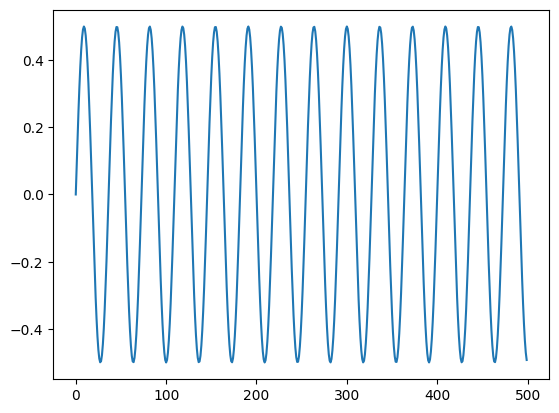

In [ ]:
plt.plot(sin_value[:500])

In [ ]:
ipd.Audio(sin_value, rate=sr)

In [ ]:
# make script to funciton
# 시간의 흐름에 해당하는 텐서 만들기
def make_sine_wave(duration, sr, frequency, amplitude):
# sr = 16000 # Hz or sample/sec
# frequency = 440 # Hz: cycle/sec
# amplitude = 0.5
  num_sample = duration * sr
  sample_t = torch.arange(num_sample) # sample
  # sample 시간 단위를 초 단위로 바꾸기
  sec_t = sample_t / sr
  freq_in_rad = frequency * 2 * pi # rad/sec
  accum_rad = sec_t * freq_in_rad # + phi
  sin_value = torch.sin(accum_rad) * amplitude
  return sin_value

sine_wave = make_sine_wave(3, 16000, 340, 2)
ipd.Audio(sine_wave, rate=sr, normalize=True)

In [ ]:
sine_wave

tensor([ 0.0000,  0.2662,  0.5277,  ..., -0.7794, -0.5276, -0.2666])

In [ ]:
# save and load wav file
import torchaudio

torchaudio.save('test.wav', sine_wave.unsqueeze(0), sample_rate=sr)



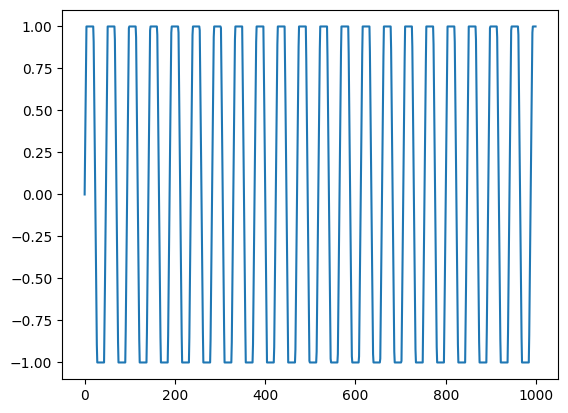

In [ ]:
loaded_audio, sr = torchaudio.load('test.wav')
plt.plot(loaded_audio[0, :1000])

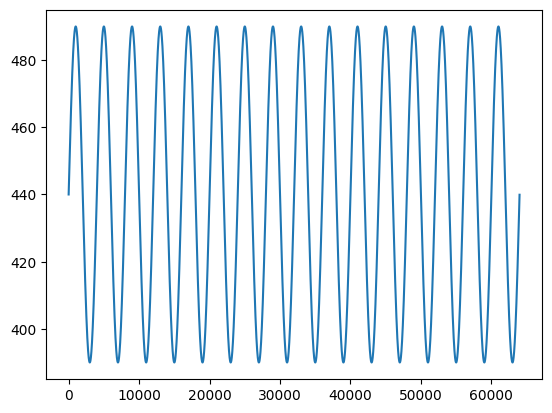

In [ ]:
# frequency가 달라질 때 sine_wave

def make_sine_wave_with_freq_seq(sr, freq_sequence, amplitude):
# sr = 16000 # Hz or sample/sec
# frequency = 440 # Hz: cycle/sec
# amplitude = 0.5
  # sample 시간 단위를 초 단위로 바꾸기
  # freq_in_rad = frequency * 2 * pi # rad/sec
  # accum_rad = sec_t * freq_in_rad # + phi
  accum_rad = torch.cumsum(freq_sequence * 2 * pi / sr, dim=0)
  sin_value = torch.sin(accum_rad) * amplitude
  return sin_value

freq_sequence = 440 + make_sine_wave(4, 16000, 4, 50)
# freq_sequence = (torch.arange(48000) / 48000) * 500 + 100
plt.plot(freq_sequence)
sine_with_vibrato = make_sine_wave_with_freq_seq(16000, freq_sequence, 0.5)
ipd.Audio(sine_with_vibrato*0.2, rate=16000, normalize=False)

In [ ]:
dummy_tensor = torch.arange(10)
print(dummy_tensor)
torch.cumsum(dummy_tensor, dim=0)

# cum_value = 0
# for x in dummy_tensor:
#   cum_value += x
torch.cumsum(freq_sequence * 2 * pi / 16000, dim=0)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


tensor([ 0,  1,  3,  6, 10, 15, 21, 28, 36, 45])

In [ ]:
# 함수를 클래스로 변환
import random

class SineGenerator:
  def __init__(self, sr, duration):
    self.sr = sr
    self.duration = duration

  def make_random_wav(self, frequency):
    num_harmonics = random.randint(1, 10)
    amp_per_harmonics = [ random.random() / (i+1)**0.5 for i in range(num_harmonics)]

    wavs = [self(frequency * (i+1), amp_per_harmonics[i]) for i in range(num_harmonics)]
    # wavs = torch.stack(wavs, dim=0)
    # return wavs.sum(dim=0)
    return sum(wavs)


  def __call__(self, frequency, amplitude):
    num_sample = self.duration * self.sr
    sample_t = torch.arange(num_sample) # sample
    # sample 시간 단위를 초 단위로 바꾸기
    sec_t = sample_t / self.sr
    freq_in_rad = frequency * 2 * pi # rad/sec
    accum_rad = sec_t * freq_in_rad # + phi
    sin_value = torch.sin(accum_rad) * amplitude
    return sin_value

oscilator = SineGenerator(sr=16000, duration=4)

wav = oscilator(440, 0.3)
ipd.Audio(wav, rate=oscilator.sr)
wav2 = oscilator(660, 0.2)

wav_sum = wav + wav2
ipd.Audio(wav_sum, rate=oscilator.sr, normalize=False)

ipd.Audio(oscilator.make_random_wav(442)*0.03, rate=oscilator.sr, normalize=False)

In [ ]:
f0 = 220
f1 = f0 * 2
f2 = f0 * 3

wav_harmonics = oscilator(f0, 0.5) + oscilator(f1, 0.2) + oscilator(f2, 0.9)
ipd.Audio(wav_harmonics*0.2, rate=sr, normalize=False)

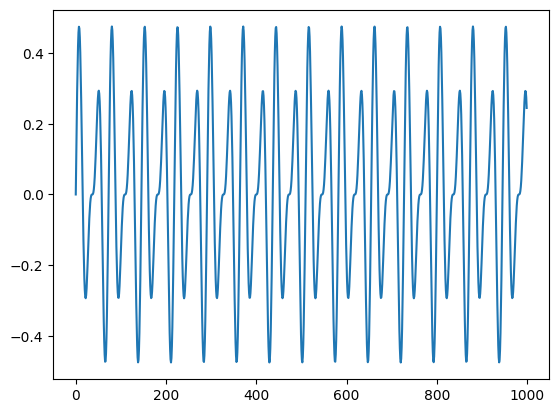

In [ ]:
plt.plot(wav_sum[:1000])

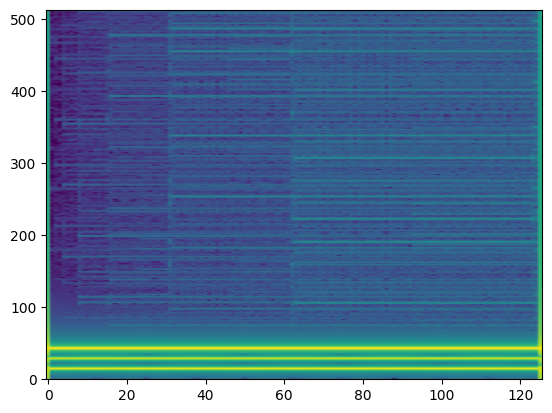

In [ ]:
# make stft of given sound
spec_converter = torchaudio.transforms.Spectrogram(n_fft=1024, hop_length=512)
db_converter = torchaudio.transforms.AmplitudeToDB()
# torchaudio.functional.spectrogram()
spec = spec_converter(wav_harmonics)
# spec = spec_converter(sine_with_vibrato)
spec = db_converter(spec)
plt.imshow(spec, origin='lower', aspect='auto')

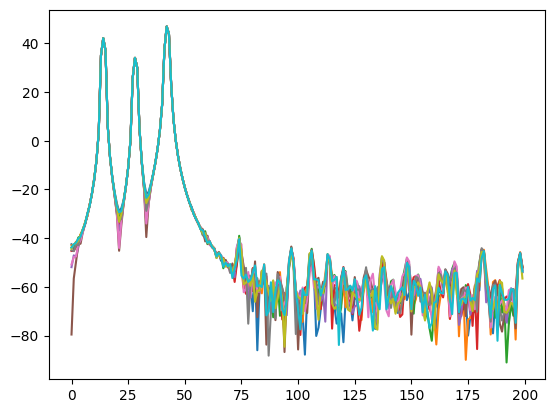

In [ ]:
spec.shape # F x T
# select 50th time frame

for t_i in range(45, 55):
  spectrum = spec[:200, t_i]
  plt.plot(spectrum)

In [ ]:
# 학습용 데이터셋 만들기
from tqdm.auto import tqdm

freq_classes = [220, 440, 660, 215]
num_samples = 1000

training_data = [] # (audio, label)

for freq in freq_classes:
  print(freq)
  for _ in tqdm(range(num_samples)):
    wav = oscilator.make_random_wav(freq)
    pair = (wav, freq)
    training_data.append(pair)


220


  0%|          | 0/1000 [00:00<?, ?it/s]

440


  0%|          | 0/1000 [00:00<?, ?it/s]

660


  0%|          | 0/1000 [00:00<?, ?it/s]

215


  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
class Dataset:
  def __init__(self, data):
    self.data = data
    # get unique data class
    entire_labels = [pair[1] for pair in self.data]
    unique_labels = set(entire_labels)
    self.class_name = sorted(unique_labels)

    # get spec converter
    self.spec_converter = torchaudio.transforms.Spectrogram(n_fft=1024, hop_length=512)
    self.db_converter = torchaudio.transforms.AmplitudeToDB()

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    pair = self.data[idx]
    audio, freq_name = pair
    class_idx = self.class_name.index(freq_name)

    spec = self.spec_converter(audio)
    spec = self.db_converter(spec)

    spectrum = spec[:, spec.shape[1]//2]
    spectrum /= 80 # scaling
    return spectrum, class_idx

dataset = Dataset(training_data)
dataset[0]
# dataset.class_name

(tensor([    -0.5952,     -0.6201,     -0.5459,     -0.4854,     -0.4551,
             -0.4037,     -0.3687,     -0.3163,     -0.2661,     -0.2065,
             -0.1286,     -0.0339,      0.1113,      0.5077,      0.5962,
              0.5338,      0.1433,     -0.0135,     -0.1152,     -0.1893,
             -0.2445,     -0.2762,     -0.3015,     -0.2827,     -0.2401,
             -0.1548,     -0.0210,      0.3024,      0.4050,      0.3548,
              0.0434,     -0.1165,     -0.2079,     -0.2531,     -0.2692,
             -0.2479,     -0.2136,     -0.1604,     -0.0916,     -0.0005,
              0.1328,      0.4153,      0.5326,      0.4946,      0.2294,
              0.0560,     -0.0520,     -0.1305,     -0.1909,     -0.2361,
             -0.2709,     -0.2712,     -0.2526,     -0.1857,     -0.0683,
              0.1833,      0.3163,      0.2901,      0.0595,     -0.1206,
             -0.2242,     -0.2816,     -0.3053,     -0.2880,     -0.2624,
             -0.2103,     -0.1447,    

In [ ]:
data_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

for batch in data_loader:
  # print(batch)
  spectrum, label = batch
  break

In [ ]:
spectrum.shape

torch.Size([64, 513])

In [ ]:
import torch.nn as nn

model = nn.Linear(in_features=513, out_features=4)
logit = model(spectrum) # N x 4
prob = logit.softmax(dim=-1)
prob_of_correct_class = prob[torch.arange(len(label)), label]
negative_log_likelihood = -torch.log(prob_of_correct_class + 1e-6)
loss = negative_log_likelihood.mean()
# prob[:6], label[:6], prob_of_correct_class[:6], negative_log_likelihood[:6]

(tensor([[0.1619, 0.2905, 0.2255, 0.3222],
         [0.1338, 0.3731, 0.2241, 0.2689],
         [0.1606, 0.2442, 0.2769, 0.3183],
         [0.1177, 0.3822, 0.2149, 0.2851],
         [0.1817, 0.2337, 0.2500, 0.3347],
         [0.1168, 0.3746, 0.1977, 0.3109]], grad_fn=<SliceBackward0>),
 tensor([3, 0, 3, 1, 3, 0]),
 tensor([0.3222, 0.1338, 0.3183, 0.3822, 0.3347, 0.1168],
        grad_fn=<SliceBackward0>),
 tensor([1.1327, 2.0114, 1.1447, 0.9618, 1.0947, 2.1477],
        grad_fn=<SliceBackward0>))

In [ ]:
# model = nn.Linear(in_features=513, out_features=4)
# optimizer = torch.optim.Adam(model.parameters())

loss_record = []
num_epochs = 2

for epoch in range(num_epochs):
  for batch in tqdm(data_loader):
    spectrum, label = batch
    logit = model(spectrum) # N x 4
    prob = logit.softmax(dim=-1)
    prob_of_correct_class = prob[torch.arange(len(label)), label]
    negative_log_likelihood = -torch.log(prob_of_correct_class + 1e-6)
    loss = negative_log_likelihood.mean()

    # backpropagation
    loss.backward()
    # update parameters using gradient
    optimizer.step()

    optimizer.zero_grad() # reset gradient
    loss_record.append(loss.item())

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

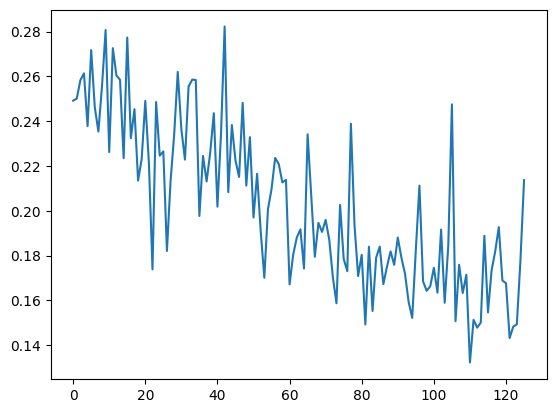

In [ ]:
plt.plot(loss_record)

In [ ]:
model.weight.shape

torch.Size([4, 513])

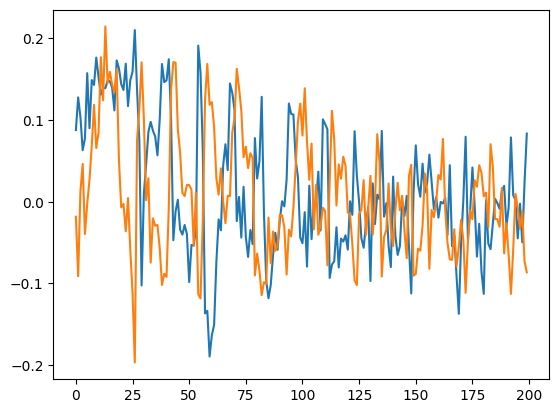

In [ ]:
for idx in range(2):
  plt.plot(model.weight[idx].data[:200])